## Event Study Analysis of Demonetization and Its Effects on SBI Index

#### 1. Import necessary libraries

In [1]:
import pandas as pd
from datetime import datetime
from scipy import stats
import yfinance as yf 
import matplotlib.pyplot as plt 
import seaborn as sns 
import statsmodels.api as sm

plt.style.use('seaborn-v0_8-darkgrid') 
import warnings
warnings.filterwarnings('ignore') 

#### 2. Fetching data

In [2]:
# Define the stock ticker and date range
ticker = "SBIN.NS"  
benchmark_ticker = "^NSEI" 

start_event = "2016-11-08"
end_event = "2016-12-30"

start_date = "2016-08-08"
end_date = "2017-03-30"

sbi_data = pd.DataFrame() 
# Download the data
sbi_data = yf.download(ticker, start=start_date, end=end_date) 
sbi_data['bench'] = yf.download(benchmark_ticker, start=start_date, end=end_date)['Adj Close'] 

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


In [3]:
sbi_data.head()

,Open,High,Low,Close,Adj Close,Volume,bench
Date,,,,,,,
2016-08-08,233.949997,235.899994,231.699997,233.250000,217.577591,16972827,8711.349609
2016-08-09,234.250000,238.000000,232.649994,235.149994,219.349915,19854185,8678.250000
2016-08-10,236.750000,236.899994,231.050003,231.500000,215.945160,16279843,8575.299805
2016-08-11,231.500000,231.600006,226.100006,227.149994,211.887436,16673286,8592.150391
2016-08-12,227.000000,247.949997,224.399994,243.300003,226.952316,86616475,NaN


In [4]:
print('Total NaN values before dropping : ',sbi_data['bench'].isna().sum())  
sbi_data.dropna(inplace=True) 
print('Total NaN values after dropping : ',sbi_data['bench'].isna().sum())   

Total NaN values before dropping :  1
Total NaN values after dropping :  0


#### 3. Plotting the dates of event

Text(0, 0.5, 'Adj Close Price')

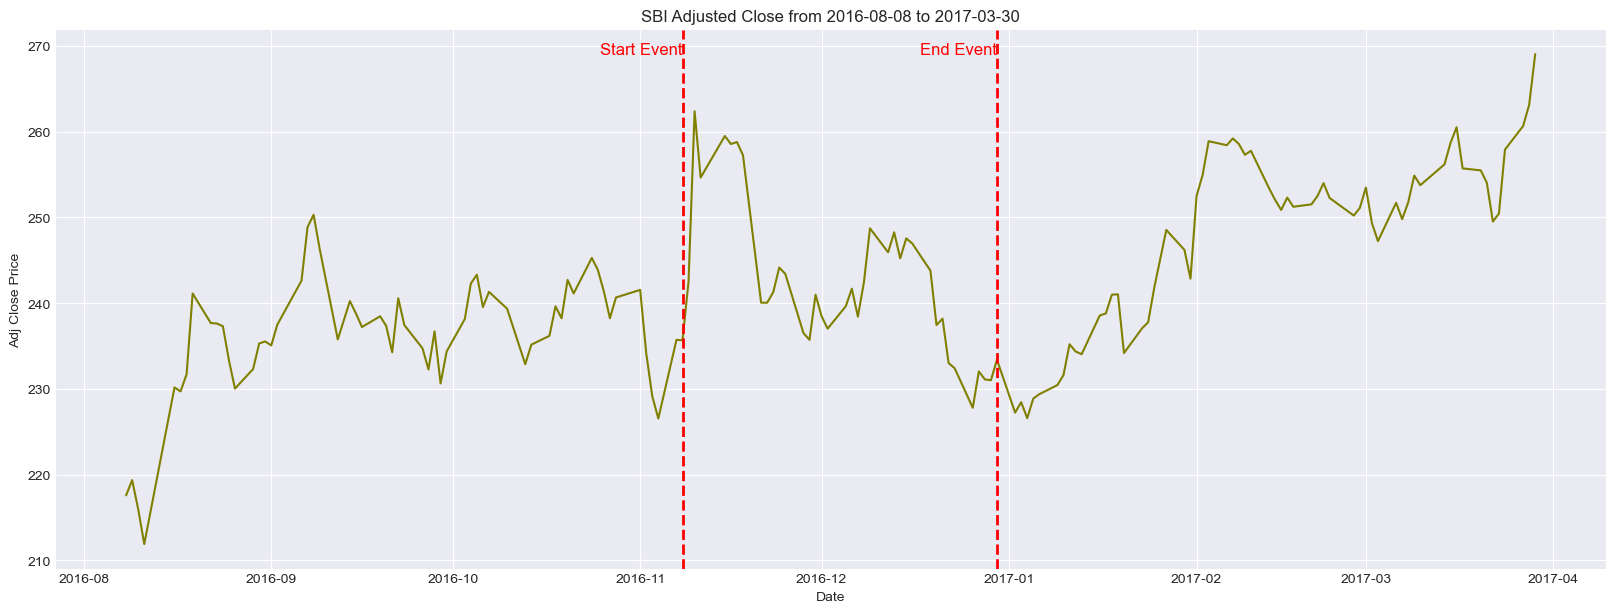

In [5]:
plt.figure(figsize=(20,7)) 
plt.plot(sbi_data.index, sbi_data['Adj Close'], label='SBI Adjusted Close', color='olive')

plt.xticks(rotation=0) 

plt.axvline(pd.to_datetime(start_event), color='red', linestyle='--', lw=2, label='Start Event')
plt.axvline(pd.to_datetime(end_event), color='red', linestyle='--', lw=2, label='End Event')
plt.text(pd.to_datetime(start_event), sbi_data['Adj Close'].max(), 'Start Event', color='red', fontsize=12, ha='right')
plt.text(pd.to_datetime(end_event), sbi_data['Adj Close'].max(), 'End Event', color='red', fontsize=12, ha='right')
plt.title(f'SBI Adjusted Close from {start_date} to {end_date}')
plt.xlabel('Date') 
plt.ylabel('Adj Close Price') 

Text(0, 0.5, 'Adj Close Price')

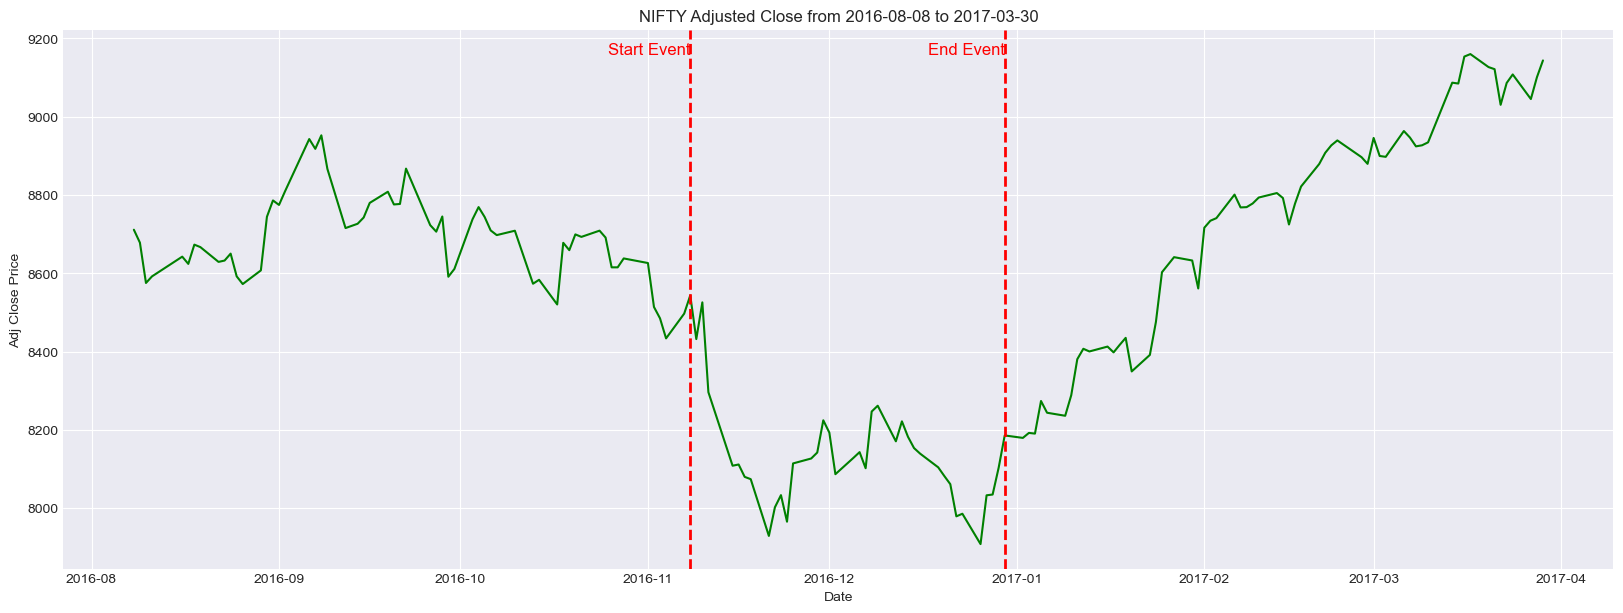

In [6]:
plt.figure(figsize=(20,7)) 

plt.plot(sbi_data.index, sbi_data['bench'], label='Nifty Adjusted Close', color='green')

plt.xticks(rotation=0) 

plt.axvline(pd.to_datetime(start_event), color='red', linestyle='--', lw=2, label='Start Event')
plt.axvline(pd.to_datetime(end_event), color='red', linestyle='--', lw=2, label='End Event')
plt.text(pd.to_datetime(start_event), sbi_data['bench'].max(), 'Start Event', color='red', fontsize=12, ha='right')
plt.text(pd.to_datetime(end_event), sbi_data['bench'].max(), 'End Event', color='red', fontsize=12, ha='right')
plt.title(f'NIFTY Adjusted Close from {start_date} to {end_date}')
plt.xlabel('Date') 
plt.ylabel('Adj Close Price') 

#### 4. Calculate returns

In [7]:
sbi_data['Daily Return'] = sbi_data['Adj Close'].pct_change()
sbi_data['bench Return'] = sbi_data['bench'].pct_change()
sbi_data.dropna(inplace=True)
sbi_data.head() 

,Open,High,Low,Close,Adj Close,Volume,bench,Daily Return,bench Return
Date,,,,,,,,,
2016-08-09,234.250000,238.000000,232.649994,235.149994,219.349915,19854185,8678.250000,0.008146,-0.003800
2016-08-10,236.750000,236.899994,231.050003,231.500000,215.945160,16279843,8575.299805,-0.015522,-0.011863
2016-08-11,231.500000,231.600006,226.100006,227.149994,211.887436,16673286,8592.150391,-0.018791,0.001965
2016-08-16,245.250000,247.899994,242.649994,246.750000,230.170502,27709873,8642.549805,0.086287,0.005866
2016-08-17,246.449997,249.800003,244.300003,246.250000,229.704086,18294050,8624.049805,-0.002026,-0.002141


#### 5. Estimate Normal Returns using Regression model

In [8]:
X = sm.add_constant(sbi_data['bench Return'])
y = sbi_data['Daily Return']  

model = sm.OLS(y, X).fit() 

#### 6. Calculate Abnormal Returns

In [9]:
sbi_data['Expected Return'] = model.predict(sm.add_constant(sbi_data['Daily Return'].shift(1)))
sbi_data['Abnormal Return'] = sbi_data['Daily Return'] - sbi_data['Expected Return'] 

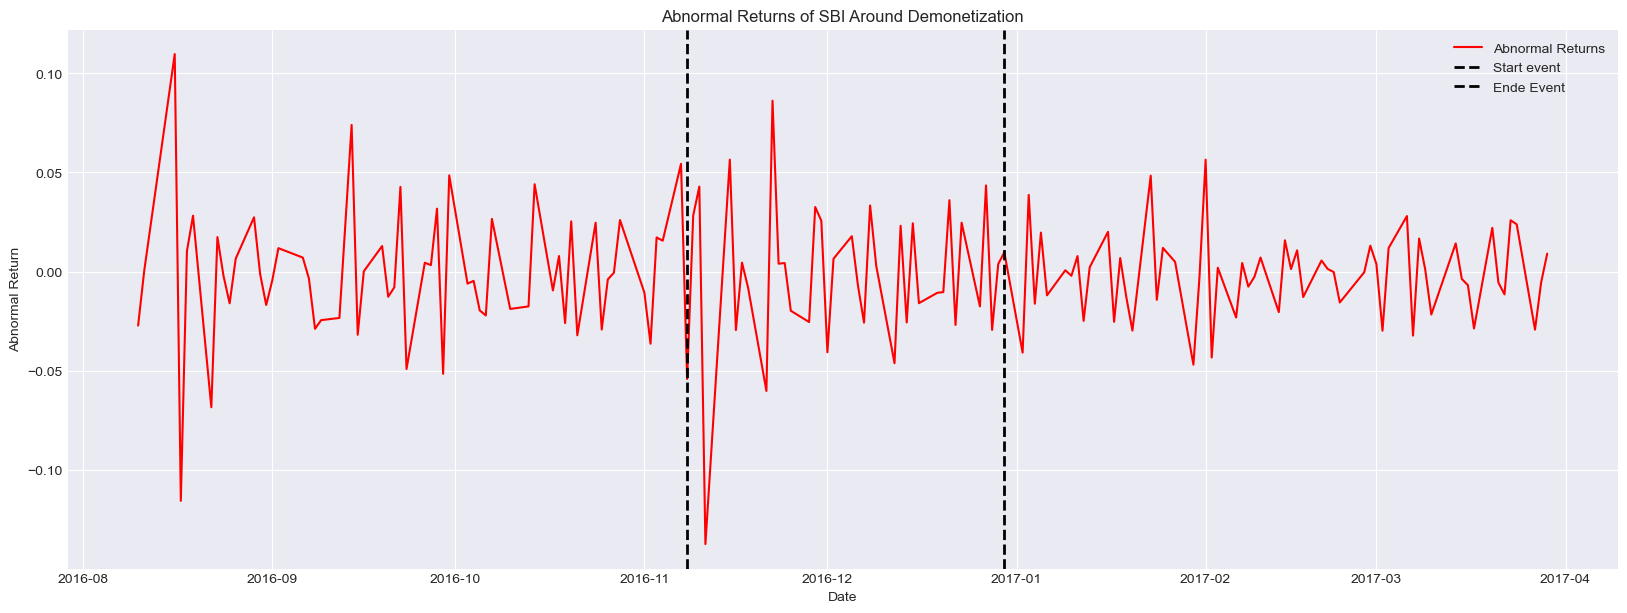

In [16]:
# Plot Abnormal Returns
plt.figure(figsize=(20, 7))
plt.plot(sbi_data.index, sbi_data['Abnormal Return'], label='Abnormal Returns', color='red')

plt.axvline(pd.to_datetime(start_event), color='black', linestyle='--', lw=2, label='Start event')
plt.axvline(pd.to_datetime(end_event), color='black', linestyle='--', lw=2, label='Ende Event')
plt.xlabel('Date')
plt.ylabel('Abnormal Return')
plt.title('Abnormal Returns of SBI Around Demonetization')
plt.legend()
plt.show() 

In [11]:
event_data = pd.DataFrame()
event_data = sbi_data[(sbi_data.index >= start_event) & (sbi_data.index <= end_event)] 
event_data.head() 

,Open,High,Low,Close,Adj Close,Volume,bench,Daily Return,bench Return,Expected Return,Abnormal Return
Date,,,,,,,,,,,
2016-11-08,253.699997,254.100006,248.649994,252.649994,235.674042,9367228,8543.549805,-0.000198,0.005472,0.054003,-0.054201
2016-11-09,235.000000,261.049988,235.000000,260.000000,242.530182,31761606,8432.000000,0.029092,-0.013057,0.000826,0.028266
2016-11-10,267.000000,284.200012,265.250000,281.299988,262.399017,50227559,8525.750000,0.081923,0.011118,0.039040,0.042883
2016-11-11,278.750000,288.799988,270.500000,273.000000,254.656754,57937113,8296.299805,-0.029506,-0.026913,0.107970,-0.137476
2016-11-15,275.149994,283.450012,270.700012,278.200012,259.507355,48658808,8108.450195,0.019048,-0.022643,-0.037413,0.056460


#### 8. Conduct Statistical Analysis 

In [14]:
# Perform a t-test to assess the significance of abnormal returns
t_stat, p_value = stats.ttest_1samp(event_data['Abnormal Return'], 0)

print("Event Study Results:")
print("T-statistic:", t_stat)
print("p-value:", p_value) 

Event Study Results:
T-statistic: -0.334664854115018
p-value: 0.7397677445784192
